In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

uploaded = files.upload()

csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

print(df.head())
print(df.columns)

Saving results.csv to results.csv
  dataset    n                  algorithm    time_us  char_ops
0  random  100             A1m_merge_sort   562.4860     608.0
1  random  100      A1q_string_quick_sort    39.6286     708.0
2  random  100         A1r_msd_radix_sort   230.2570     354.0
3  random  100  A1rq_msd_radix_quick_sort    59.1714     341.0
4  random  200             A1m_merge_sort  1055.9000    1496.0
Index(['dataset', 'n', 'algorithm', 'time_us', 'char_ops'], dtype='object')


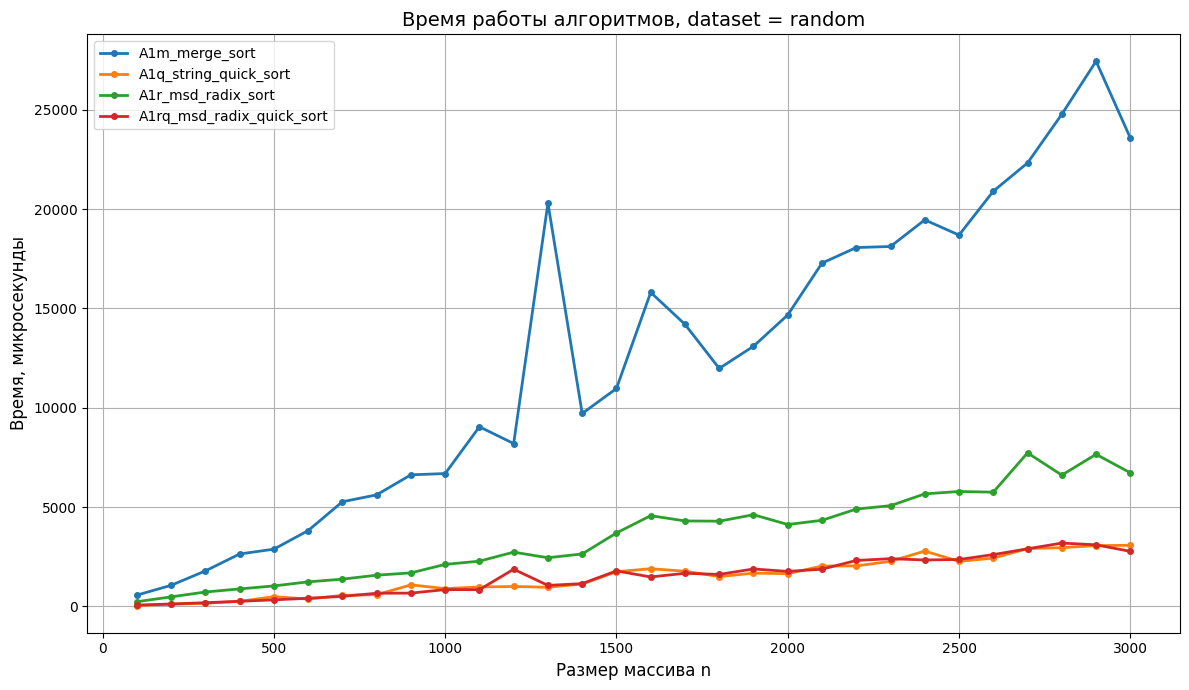

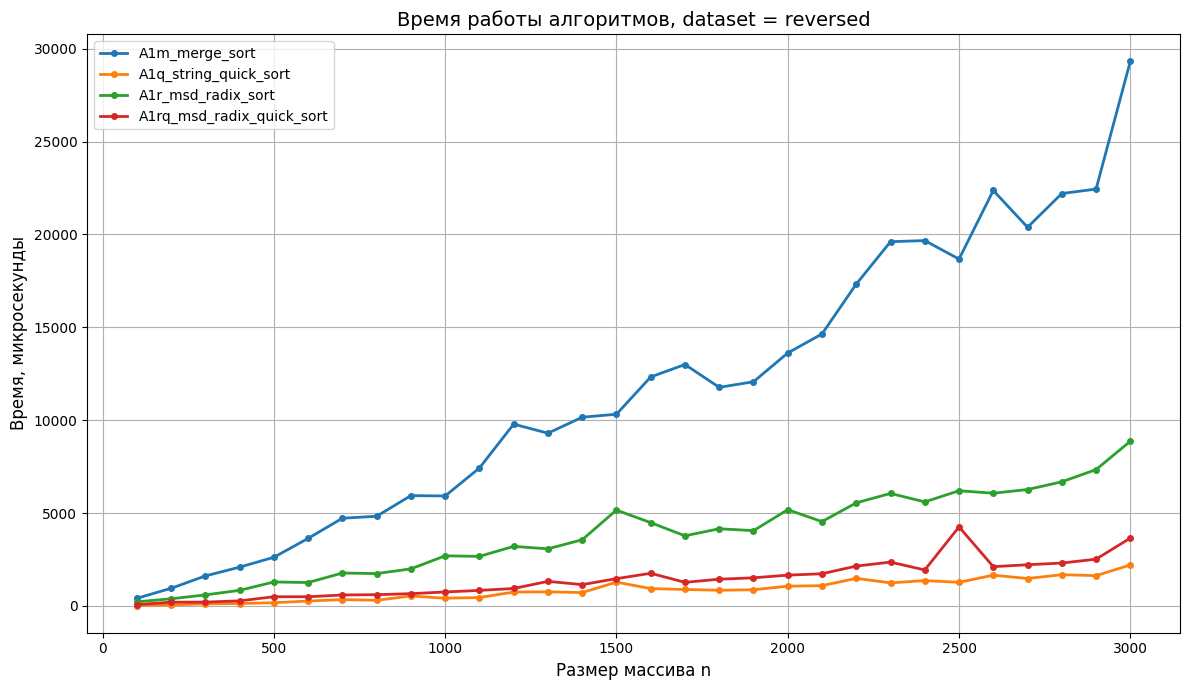

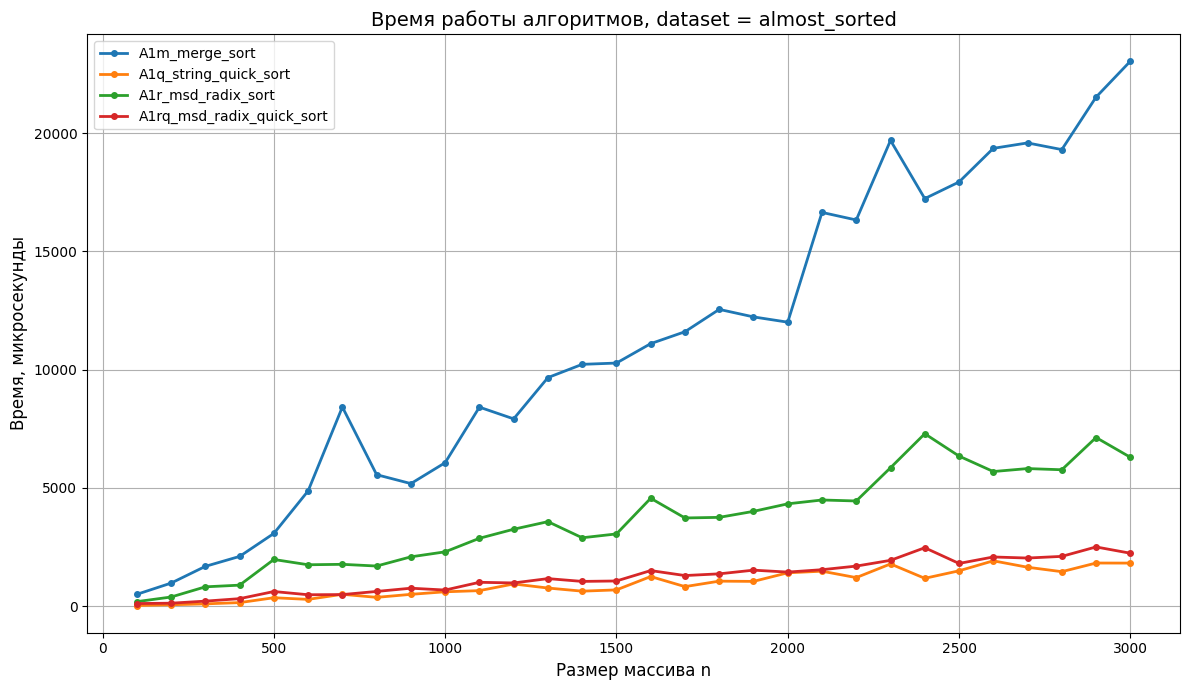

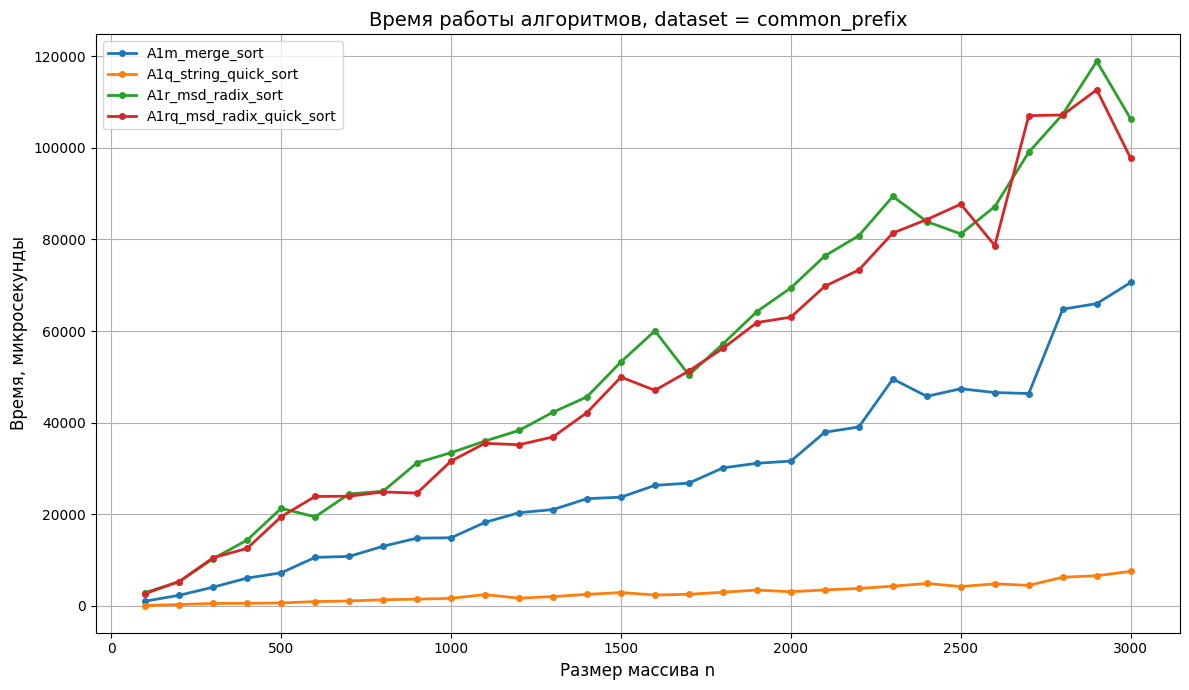

In [2]:
os.makedirs("plots", exist_ok=True)

datasets = df["dataset"].unique()
algorithms = df["algorithm"].unique()

for dataset in datasets:
    cur = df[df["dataset"] == dataset]

    plt.figure(figsize=(12, 7))

    for alg in algorithms:
        part = cur[cur["algorithm"] == alg]
        if len(part) == 0:
            continue

        plt.plot(
            part["n"],
            part["time_us"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=alg
        )

    plt.title(f"Время работы алгоритмов, dataset = {dataset}", fontsize=14)
    plt.xlabel("Размер массива n", fontsize=12)
    plt.ylabel("Время, микросекунды", fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    path = f"plots/time_{dataset}.png"
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()

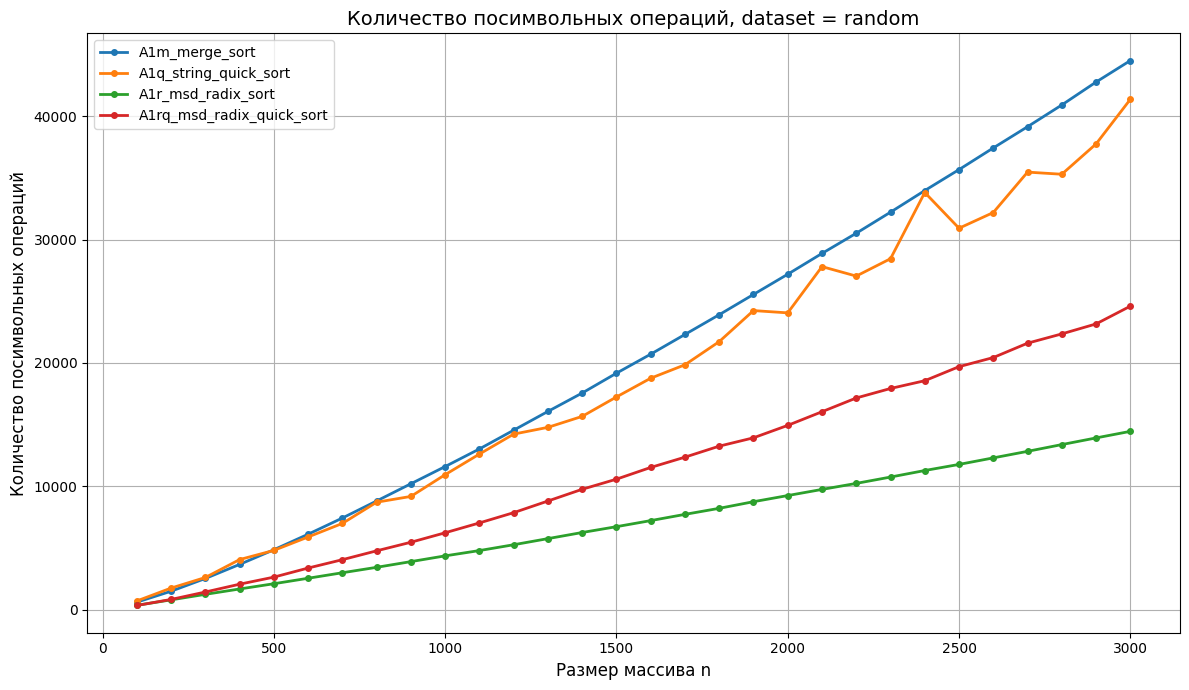

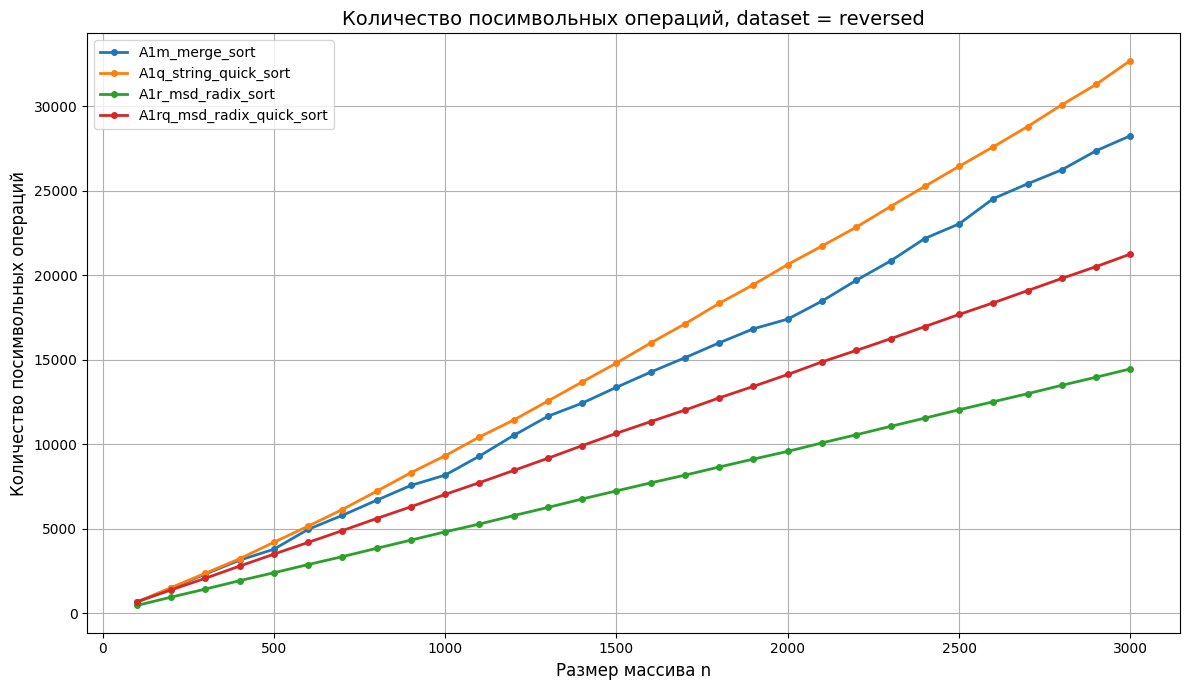

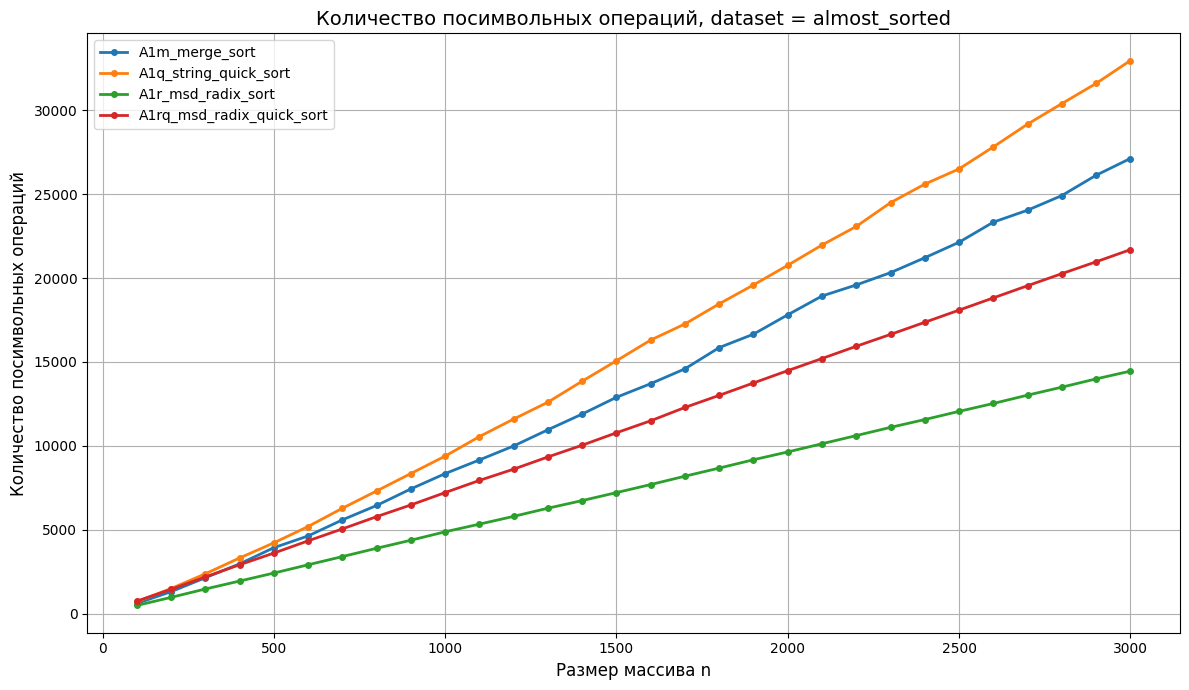

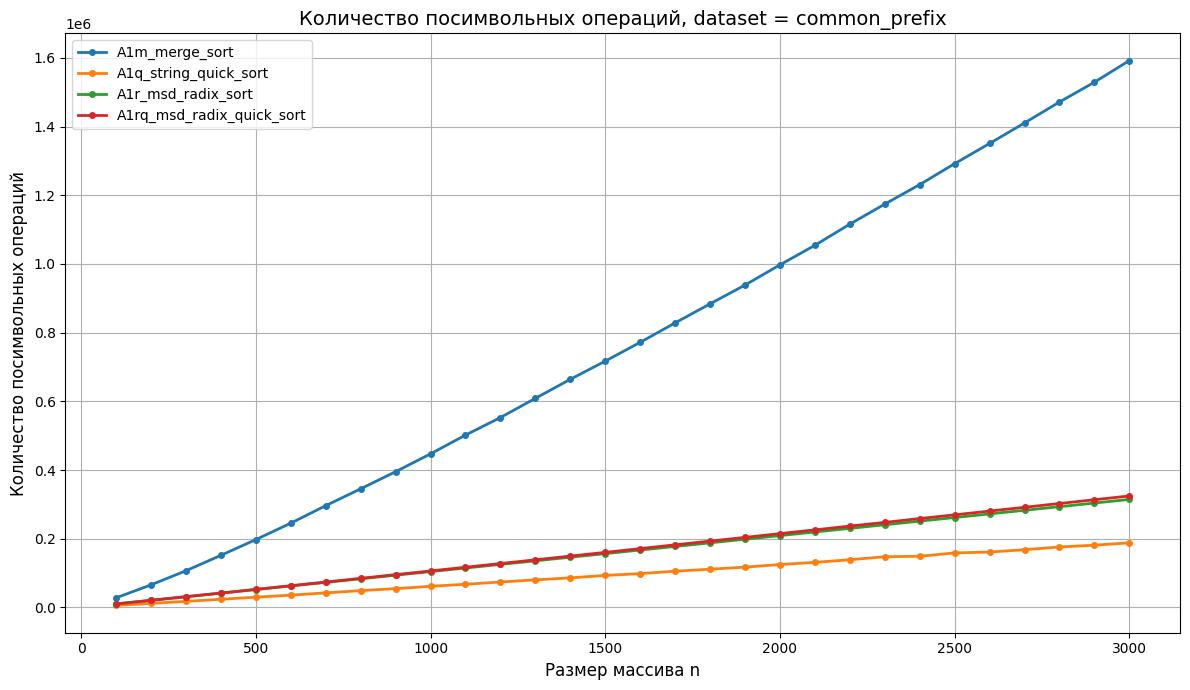

In [3]:
for dataset in datasets:
    cur = df[df["dataset"] == dataset]

    plt.figure(figsize=(12, 7))

    for alg in algorithms:
        part = cur[cur["algorithm"] == alg]
        if len(part) == 0:
            continue

        plt.plot(
            part["n"],
            part["char_ops"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=alg
        )

    plt.title(f"Количество посимвольных операций, dataset = {dataset}", fontsize=14)
    plt.xlabel("Размер массива n", fontsize=12)
    plt.ylabel("Количество посимвольных операций", fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    path = f"plots/ops_{dataset}.png"
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()

In [4]:
shutil.make_archive("plots", "zip", "plots")
files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
summary = (
    df
    .groupby(["dataset", "algorithm"], as_index=False)
    .agg(
        avg_time_us=("time_us", "mean"),
        avg_char_ops=("char_ops", "mean")
    )
    .sort_values(["dataset", "avg_time_us"])
)

summary

,dataset,algorithm,avg_time_us,avg_char_ops
1,almost_sorted,A1q_string_quick_sort,937.269047,15944.133333
3,almost_sorted,A1rq_msd_radix_quick_sort,1243.260200,11201.366667
2,almost_sorted,A1r_msd_radix_sort,3634.878133,7481.400000
0,almost_sorted,A1m_merge_sort,11167.288200,13489.333333
5,common_prefix,A1q_string_quick_sort,2850.088567,96441.266667
4,common_prefix,A1m_merge_sort,28395.166333,765600.333333
7,common_prefix,A1rq_msd_radix_quick_sort,51954.776333,166435.400000
6,common_prefix,A1r_msd_radix_sort,54506.215667,162142.466667
9,random,A1q_string_quick_sort,1484.801820,18964.133333
11,random,A1rq_msd_radix_quick_sort,1495.718313,11426.966667


In [6]:
summary.to_csv("summary.csv", index=False)
files.download("summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>